# Tablero

la representacion mas basica del tablero es self.tablero:

In [289]:
# imports necesarios

import numpy as np
import random
import matplotlib.pyplot as plt

Vamos a explicar poco a poco cada uno de los objetos que hemos implementado para resolver el problema.

# Tablero

Se define un tablero a partir del tamaño de deseado en filas y columnnas.

### Generacion del trablero.

Se genera el tablero a partir de un punto final y uno inicial en los bordes. Se generan una serie de puntos leatorio y se unen mediante interpolacion lineal (quizas un mentodo mas sofisticado hubiera dado lugar a mejores curvas), y se rellenan los huecos entre las lineas generadas.

### Representaciones.

La representacion que se usa internamente es una matriz de numpy, con la siguiente codificacion:

- 0: pared
- 1: casilla vacia
- 2: casilla inicial
- 3: casilla final

tambien se implementa una funcion para dibujarlo mediante matplotlib.

<img src="imagenes_parte_1/tablero.png" style="width: 300px;"/>

### Posiciones inicial y final

Las posiciones iniciales y finales posibles se guardan en atributos del objeto tablero, para facilitar su acceso desde otros objetos.




In [290]:
class Tablero:
    def __init__(self, rows, columns, array_tablero=None):
        self.rows = rows
        self.columns = columns
        self.tablero = np.ones((rows, columns), dtype=int)

        # Listas para guardar las posiciones de salida y la meta
        self.start_pos = []
        self.finish_pos = []

        # Comprueba si se le pasa un tablero predefinido
        if array_tablero is not None:
            self.tablero = array_tablero
            self.rows, self.columns = array_tablero.shape
            self.start_pos = [(int(x), int(y)) for x, y in zip(*np.where(self.tablero == 2))]
            self.finish_pos = [(int(x), int(y)) for x, y in zip(*np.where(self.tablero == 3))]


    def generar_curva(self, puntos_intermedios=1, ancho=2):
        '''
        Este método genera aleatoriamente un circuito en función
        de los parámetros de entrada.
        '''

        # Define la salida y la meta
        start = (self.rows - 1, random.randint(0, self.columns - 1))
        finish = (random.randint(0, self.rows - 1), self.columns - 1)

        puntos_intermedios = [
            (random.randint(0, self.rows - 1), random.randint(0, self.columns - 1)) for _ in range(puntos_intermedios)
        ]

        puntos = [start] + puntos_intermedios + [finish]

        for i in range(len(puntos) - 1):
            x1, y1 = puntos[i]
            x2, y2 = puntos[i + 1]

            # Definimos el vector director
            v_x = x2 - x1
            v_y = y2 - y1

            num_steps = max(abs(x2 - x1), abs(y2 - y1))

            for step in range(num_steps + 1):

                alfa = step / num_steps

                x = int(x1 + alfa * (v_x))
                y = int(y1 + alfa * (v_y))
                
                for dx in range(-ancho, ancho + 1):
                    for dy in range(-ancho, ancho + 1):
                        if 0 <= x + dx < self.rows and 0 <= y + dy < self.columns:
                            self.tablero[x + dx, y + dy] = 0


        for i in range(-ancho, ancho + 1):

            if 0 <= start[1] + i < self.columns:
                posible_start_pos = (start[0], start[1] + i)
                if self.tablero[posible_start_pos] == 0:
                    self.tablero[posible_start_pos] = 2
                    self.start_pos.append(posible_start_pos)

            if 0 <= finish[0] + i < self.rows:
                posible_finish_pos = (finish[0] + i, finish[1])
                if self.tablero[posible_finish_pos] == 0:
                    self.tablero[posible_finish_pos] = 3
                    self.finish_pos.append(posible_finish_pos)


    def dibujar(self):
        '''
        Dibuja una imagen con el circuito generado.
        '''
        colores = {
            0: (0, 0, 0),       # Negro -> Pista
            1: (255, 255, 255), # Blanco -> Muro
            2: (255, 0, 0),     # Rojo -> Salida
            3: (0, 255, 0),     # Verde -> Meta
        }

        img = np.zeros((self.rows, self.columns, 3), dtype=np.uint8)
        for i in range(self.rows):
            for j in range(self.columns):
                img[i, j] = colores[self.tablero[i, j]]

        plt.axis('off')
        plt.imshow(img)
        plt.show()


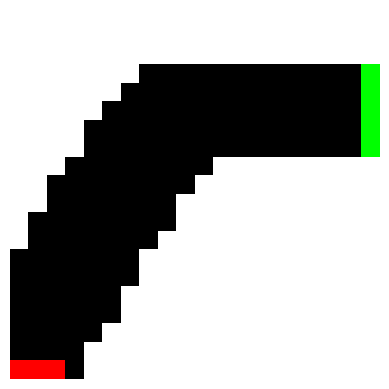

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
       [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
       [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
       [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
       [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
       [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 1,

In [291]:
# Ejemplo de uso

t1 = Tablero(20, 20) # Tablero de 20x20
t1.generar_curva() # Generar una curva aleatoria
t1.dibujar() # Representacion del tablero grafica
t1.tablero # Representacion del tablero en matriz

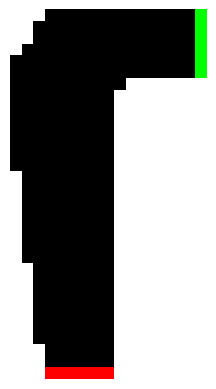

In [292]:
circuito1 = np.ones(shape=(32, 17))
# Salida
circuito1[-1, 3:9] = 2
# Meta
circuito1[:6, -1] = 3
# Pista
circuito1[:-1, 3:9] = 0
circuito1[:7, 9] = 0
circuito1[:6, 10:-1] = 0
circuito1[1:-3, 2] = 0
circuito1[3:-10, 1] = 0
circuito1[4:14, 0] = 0

t2 = Tablero(20, 20, circuito1)
t2.dibujar()

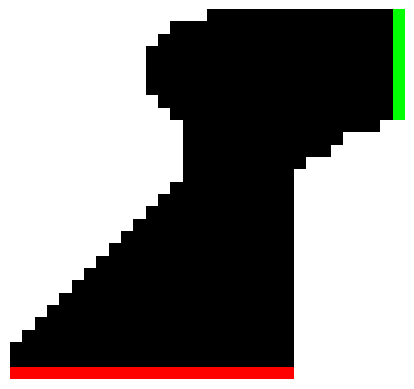

In [293]:
circuito2 = np.ones(shape=(30, 32))
# Salida
circuito2[-1, :-9] = 2
# Meta
circuito2[:9, -1] = 3
# Pista
circuito2[1:-1, 14:16] = 0
circuito2[:-1, 16:23] = 0
for j in range(0, 14):
    circuito2[-3-j:-1, j] = 0
circuito2[1:9, 13] = 0
circuito2[2:8, 12] = 0
circuito2[3:7, 11] = 0
circuito2[:9, -9:-1] = 0
circuito2[9, -9:-2] = 0
circuito2[10, -9:-5] = 0
circuito2[11, -9:-6] = 0
circuito2[12, -9:-8] = 0

t3 = Tablero(20, 20, circuito2)
t3.dibujar()

# Estado.

Un estado vendra definido por la tupla, (posicion, velocidad), donde a su vez la posicion viene definida por una tupla (fila, columna), y la velocidad por otra tupla (velocidad_fila, velocidad_columna). Dada una posicion y una

In [294]:
class State:
    def __init__(self, position, velocity):
        self.position = position
        self.velocity = velocity



    def __repr__(self):
        return f"Pos: {self.position}, Vel: {self.velocity}"

In [295]:
s0 = State((1, 1), (1, 2))
print(s0)

Pos: (1, 1), Vel: (1, 2)


# Base method Agente

Vamos a implementar una clase basica de un agente en la que se definan metodos genericos que todo agente debe heredar. Vamos a implementar una clase basica de un agente en la queEl agente se encarga de gestionar su estado interno, y generar la respuesta es importante que el agente NO INTERACTUA con el tablero directamente, ya que el agente es model-free y no tiene conocimiento a priori del entorno.

- Reset_to_start: reinicia el estado del agente a la posicion inicial del tablero, y velocidad 0. (Inicia un nuevo episodio) Este metodo lo invoca la partida.
- posible_actions: devuelve las acciones posibles desde el estado actual. para asegurar que la velocidad no supere los limites maximos.

Por ultimo se genera el metodo abstracto `generate_response` que define la logica de seleccion de acciones del agente.

In [296]:
from abc import ABC, abstractmethod

@abstractmethod
class Agent(ABC):
    def __init__(self):
        self.state = None

    def reset_to_start(self, tablero : Tablero):
        '''
        Devuelve al agente a un estado inicial de salida aleatorio.
        '''
        start_pos = random.choice(tablero.start_pos)
        self.state = State(start_pos, (0, 0))


    def update_state(self, action):
        '''
        Actualiza el estado del agente en función de la acción tomada.
        '''
        # Actualiza la velocidad
        new_vx = self.state.velocity[0] + action[0]
        new_vy = self.state.velocity[1] + action[1]

        # Actualiza la posición
        new_x = self.state.position[0] + new_vx
        new_y = self.state.position[1] + new_vy

        # Actualiza el estado
        self.state = State((new_x, new_y), (new_vx, new_vy))


    def posible_actions(self):
        '''
        Devuelve una lista con las acciones permitadas en función del
        estado actual (Velocidad en [-5, 5] pero no ambas 0).
        '''
        actions = []
        
        # Para cada acción comprueba si está permitida
        for ax in [-1, 0, 1]:
            for ay in [-1, 0, 1]:
                new_vx = self.state.velocity[0] + ax
                new_vy = self.state.velocity[1] + ay
                # Comprueba velocidad en [-5, 5] y no ambas 0
                if (-5 <= new_vx <= 5) and (-5 <= new_vy <= 5) and not (new_vx == 0 and new_vy == 0):
                    actions.append((ax, ay))
        return actions
                    

    @abstractmethod
    def generate_response(self):
        return

Vamos a definir un primer agente aleatorio que simplemente selecciona una accion al azar entre las posibles.

In [297]:
class RandomAgent(Agent):
    def generate_response(self):

        actions = self.posible_actions()
        action = random.choice(actions)
        self.update_state(action)
        return action

In [298]:
random_agent = RandomAgent()
random_agent.reset_to_start(t1)
print("Estado inicial del agente aleatorio:")
print(random_agent.state)
print("Accion seleccionada:")
action = random_agent.generate_response()
print(action)
print("Nuevo estado del agente aleatorio:")
print(random_agent.state)

Estado inicial del agente aleatorio:
Pos: (19, 1), Vel: (0, 0)
Accion seleccionada:
(-1, 1)
Nuevo estado del agente aleatorio:
Pos: (18, 2), Vel: (-1, 1)


Comprobamos que el agente inicia en una posicion de inicio del tablero, con velocidad 0, y que tras seleccionar una accion aleatoria, su estado se actualiza correctamente.

# Traza.

La traza es una lista de tuplas (Estado, accion, recompensa), que se va actualizando a medida que el agente interactua con el entorno, permiticmo que se añadan tuplas con append y luego implementamos los metodos que usaremos para calcular g.

Nuesto objetico final sera crear una aproximacion de Q(s, a) ya que aplicaremos la max-Q policy.

$$

Q^\pi(s,a)
\;=\;
\mathbb{E}_\pi \bigl[\, V^\pi(S_1) \;\big|\; S_0 = s,\; A_0 = a \,\bigr]

$$

V se define como sumatorio de la siguiente manera

$$
V^\pi(s)
=
\mathbb{E}_\pi \Bigl[
R_1
+
\gamma R_2
+
\gamma^2 R_3
+
\cdots
+
\gamma^{T-1} R_T
\;\big|\;
S_0 = s
\Bigr]
$$

En un episodio nosotros podemos calcular el valor v(s) y lo podemos interprear como una muestra de dicha variable aleatoria. De modo que podemos aplicar la media para estimar el valor teorico que es la esperanza.

Del mismo modo podemos estimar Q(s, a) asegurandonos de que en el primer paso la accion que toma el agente es a. Asegurarnos de que siempre se encuentran casos como este supone entrar en el trade-off entre exploracion y explotacion, que abordaremos mas adelante. Escribimos la expresion de Q(s, a) como:

Y una muestra de esta variable sera G(s, a) que podemos calcular a partir de la traza.

$$
g(s,a)
=
r_1
+
\gamma r_2
+
\gamma^2 r_3
+
\cdots
+
\gamma^{T-1} r_T
\text{   con }
(s_1,a_1)=(s,a)
$$



de modo que podemos estimar Q(s, a) como la media de todas las muestras g(s, a) obtenidas en los episodios.

$$
Q(s,a)
=
\mathbb{E}\!\left[\, G(s,a) \;\middle|\; S_0=s,\; A_0=a \right]
\;\approx\;
\frac{1}{n}
\sum_{i=1}^{n} G_i(s,a)
$$

Esto tiene un problema, que es que para calcular la media necesitas simular muchos episodios, y todo para actializar la politica una sola vez, seria mas eficiente dfinir una politica de actualizacion para cada episodio (Una version online de la media muestral), me manera que que cada episocio se genera con la mejor politica posible acerlerando el aprendizaje.

In [299]:
class Traza:
    def __init__(self, discount = 0.9):
        self.discount = discount
        self.traza = []


    def append(self, tupla_traza):
        '''
        Añade el (estado, acción) a la traza.
        '''
        self.traza.append(tupla_traza)


    def __len__(self):
        return len(self.traza)
    

    def __get_reward_from_traza(self, traza, discount=True):
        '''
        Calcula la recompensa total que produce la traza de entrada.
        '''
        # Suma las recompensas de cada estado en la traza
        total = 0
        for i, tupla in enumerate(traza):
            r = tupla[2]
            if discount:
                total += r * (self.discount ** i)
            else:
                total += r
        return total
    

    def get_total_reward(self, discount=True):
        '''
        Devuelve la recompensa total que produce la traza de entrada.
        '''
        return self.__get_reward_from_traza(self.traza, discount)
    

    def get_reward_from_state(self, i_stage, discount=True):
        '''
        Calcula la recompensa asociada a un estado.
        '''
        return self.__get_reward_from_traza(self.traza[i_stage:], discount)
    

    def __repr__(self):
        return str(self.traza)

# Game

La clase game la usamo para generar un episodio dado un tablero y un agente. Retornamos la traza generada en el episodio.

In [300]:
class Game:
    def __init__(self, tablero : Tablero):
        self.tablero = tablero
    

    def trayectoria(self, pos_ini, pos_fin):
        '''
        Devuelve una lista con las casillas que recorre el agente en
        su trayectoria.
        '''
        x0, y0 = pos_ini
        x1, y1 = pos_fin

        # Calculamos la velocidad
        vx = x1 - x0
        vy = y1 - y0

        # Obtenemos el número de casillas que atraviesa en la trayectoria
        n_casillas = max(abs(vx), abs(vy))
        casillas = []

        if n_casillas == 0:
            return casillas

        # Calcula todas las casillas que recorre en la trayectoria
        for i in range(1, n_casillas + 1):
            xi = x0 + round(vx * i / n_casillas)
            yi = y0 + round(vy * i / n_casillas)
            casillas.append((xi, yi))

        return casillas
    

    def simulate_episode(self, agente : Agent, max_states=200):
        '''
        Simula un episodio completo con un máximo de pasos (max_states).
        '''
        traza = Traza(discount=0.9)
        

        def agent_is_crash(pos_ini, pos_fin):
            '''
            Comprueba si el agente se ha chocado con un muro o se ha salido
            fuera de los límites del tablero.
            '''
            trayectoria = self.trayectoria(pos_ini, pos_fin)

            for x, y in trayectoria:

                # Se ha salido del tablero
                if not (0 <= x < self.tablero.rows and 0 <= y < self.tablero.columns):
                    return True

                # Ha chocado con una pared (1 = muro en el tablero)
                if self.tablero.tablero[x, y] == 1:
                    return True

            return False

            
        def agent_is_goal():
            '''
            Comprueba si el agente ha llegado a la meta.
            '''
            pos_agente = agente.state.position
            # Verificar que la posición es válida antes de acceder
            if not(0 <= pos_agente[0] < self.tablero.rows and 0 <= pos_agente[1] < self.tablero.columns):
                return False
            # Meta = 3
            if self.tablero.tablero[pos_agente] == 3:
                return True
            return False
        
        # Definimos la casilla de salida
        agente.reset_to_start(self.tablero)

        for step in range(max_states):
            # Guardamos el estado ANTES de la acción
            estado_antes = agente.state
            pos_ini = estado_antes.position
            
            # Generamos la accion del agente (esto actualiza el estado)
            action = agente.generate_response()
            pos_fin = agente.state.position

            tupla_traza = [
                estado_antes,  # Estado antes de la acción
                action,
                -1  # Penalización por paso para incentivar llegar rápido
            ]

            # Comprobacion de meta (primero para dar prioridad a la meta)
            if agent_is_goal():
                tupla_traza[2] = 100  # Recompensa alta por llegar
                traza.append(tupla_traza)
                break

            # Comprobacion de crash
            if agent_is_crash(pos_ini, pos_fin):
                tupla_traza[2] = -10  # Penalización por crash
                agente.reset_to_start(self.tablero)

            traza.append(tupla_traza)

        return traza

Hacemos la prueba con el agente random.

In [301]:
game = Game(t1)
traza_random = game.simulate_episode(random_agent, max_states=10)
print("Traza del agente aleatorio:")

for step in traza_random.traza:
    print(step)

Traza del agente aleatorio:
[Pos: (19, 0), Vel: (0, 0), (-1, -1), -10]
[Pos: (19, 0), Vel: (0, 0), (1, 0), -10]
[Pos: (19, 1), Vel: (0, 0), (0, 1), -1]
[Pos: (19, 2), Vel: (0, 1), (1, 1), -10]
[Pos: (19, 0), Vel: (0, 0), (0, -1), -10]
[Pos: (19, 1), Vel: (0, 0), (-1, 0), -1]
[Pos: (18, 1), Vel: (-1, 0), (-1, -1), -1]
[Pos: (16, 0), Vel: (-2, -1), (0, 0), -10]
[Pos: (19, 1), Vel: (0, 0), (1, 1), -10]
[Pos: (19, 1), Vel: (0, 0), (-1, -1), -1]


In [302]:
from abc import ABC, abstractmethod

@abstractmethod
class Agent(ABC):
    def __init__(self):
        self.state = None

    def reset_to_start(self, tablero : Tablero):
        '''
        Devuelve al agente a un estado inicial de salida aleatorio.
        '''
        start_pos = random.choice(tablero.start_pos)
        self.state = State(start_pos, (0, 0))


    def update_state(self, action):
        '''
        Actualiza el estado del agente en función de la acción tomada.
        '''
        # Actualiza la velocidad
        new_vx = self.state.velocity[0] + action[0]
        new_vy = self.state.velocity[1] + action[1]

        # Actualiza la posición
        new_x = self.state.position[0] + new_vx
        new_y = self.state.position[1] + new_vy

        # Actualiza el estado
        self.state = State((new_x, new_y), (new_vx, new_vy))


    def posible_actions(self):
        '''
        Devuelve una lista con las acciones permitadas en función del
        estado actual (Velocidad en [-5, 5] pero no ambas 0).
        '''
        actions = []
        
        # Para cada acción comprueba si está permitida
        for ax in [-1, 0, 1]:
            for ay in [-1, 0, 1]:
                new_vx = self.state.velocity[0] + ax
                new_vy = self.state.velocity[1] + ay
                # Comprueba velocidad en [-5, 5] y no ambas 0
                if (-5 <= new_vx <= 5) and (-5 <= new_vy <= 5) and not (new_vx == 0 and new_vy == 0):
                    actions.append((ax, ay))
        return actions
                    

    @abstractmethod
    def generate_response(self):
        return

# Q-table

La q table asocia cada par estado accion con su valor Q(s, a), que nos sirve para evaluar una determinada accion en un estado concreto con el resto de acciones posibles, de manera que podemos seleccionar la accion con mayor valor Q(s, a) en cada estado s. Continuamos con el desarrollo de antes para llegar a la politica de actualizacion.

Como ya vimos, podemos estimar Q(s, a) como la media de todas las muestras g(s, a) obtenidas en los episodios.

$$
Q(s,a)
=
\mathbb{E}\!\left[\, G(s,a) \;\middle|\; S_0=s,\; A_0=a \right]
\;\approx\;
\frac{1}{n}
\sum_{i=1}^{n} G_i(s,a)
$$

Esto tiene un problema, que es que para calcular la media necesitas simular muchos episodios, y todo para actializar la politica una sola vez, seria mas eficiente dfinir una politica de actualizacion para cada episodio (Una version online de la media muestral), me manera que que cada episocio se genera con la mejor politica posible acerlerando el aprendizaje.

$$
Q_{c}(s,a)
=
Q_{c-1}(s,a)
+
\frac{1}{c(s,a)}
\Bigl(
G_{c}(s,a)
-
Q_{c-1}(s,a)
\Bigr)
$$


El resultado tambien se puede entender como que la politica de actualizacion es implemente movernos en la direccion del error de prediccion pero con un peso que disminuye conforme vamos actualizamos mas veces el par (s, a), que es como un factor de relajacion.

Tambien podemos definir una politica epsilon-soft, para garantizar que todos los pares (s, a) se exploran con cierta frecuencia, aunque se prioriza la explotacion de los mejores pares.

In [303]:
class Q_table:
    def __init__(self, rows, cols, q_inicial=-50):
        # Velocidades van de -5 a 5 (11 valores), acciones de -1 a 1 (3 valores)
        # Shape: (rows, cols, 11 velocidades_x, 11 velocidades_y, 3 acciones_x, 3 acciones_y)
        self.Q_table = np.full((rows, cols, 11, 11, 3, 3), q_inicial, dtype=float)
        self.value_action_pair_count = np.zeros_like(self.Q_table)

    def _vel_to_idx(self, v):
        """
        Mapea velocidad [-5, 5] a índice [0, 10]
        """
        return v + 5


    def update_Q_table(self, pos, speed, action, retorno_s, W = 1):
        # W = 1 sera manejado por la implementacion on-policy
        # W = peso importancia para off-policy
        '''
        Actualiza la matriz Q según del estado, acción y recompensa.
        '''
        p1, p2 = pos
        v1, v2 = self._vel_to_idx(speed[0]), self._vel_to_idx(speed[1])
        a1, a2 = action[0] + 1, action[1] + 1  # Mapear [-1,0,1] -> [0,1,2]

        self.value_action_pair_count[p1, p2, v1, v2, a1, a2] += W
        c = self.value_action_pair_count[p1, p2, v1, v2, a1, a2]

        q_value = self.Q_table[p1, p2, v1, v2, a1, a2]
        self.Q_table[p1, p2, v1, v2, a1, a2] += (1 / c) * (retorno_s - q_value)


    def _valid_action_for_state(self, speed, action):
        '''
        Comprueba si la acción está permitida para ese estado.
        '''
        new_vx = speed[0] + action[0]
        new_vy = speed[1] + action[1]
        # Velocidad en [-5, 5] (intervalo cerrado) pero no ambas 0
        if (-5 <= new_vx <= 5) and (-5 <= new_vy <= 5) and not (new_vx == 0 and new_vy == 0):
            return True
        return False


    def _max_q_policy(self, pos, speed):
        '''
        Devuelve la mejor acción según la política actual.
        '''
        v1, v2 = self._vel_to_idx(speed[0]), self._vel_to_idx(speed[1])
        Q_slice = self.Q_table[pos[0], pos[1], v1, v2, :, :]

        best_action = None
        best_Q_value = -np.inf

        for i in range(3):
            for j in range(3):
                a_i = i - 1  # Mapear [0,1,2] -> [-1,0,1]
                a_j = j - 1

                if self._valid_action_for_state(speed, (a_i, a_j)):
                    Q_value = Q_slice[i, j]
                    if Q_value > best_Q_value:
                        best_action = (a_i, a_j)
                        best_Q_value = Q_value
        
        return best_action


    def eps_soft_policy(self, pos, speed, eps):
        '''
        Política soft que devuelve una acción aleatoria con una
        determinada probabilidad.
        '''
        if random.random() < eps:
            actions = [(a1, a2) for a1 in [-1, 0, 1] for a2 in [-1, 0, 1] if self._valid_action_for_state(speed, (a1, a2))]
            return random.choice(actions)
        else:
            return self._max_q_policy(pos, speed)

Con esto ya podemos definir a un agente que siga esta politica epsilon-soft.


In [304]:
class Eps_soft_policy_agent(Agent):
    def __init__(self, eps, n_rows, n_cols):
        super().__init__()
        self.eps = eps
        self.Q_table = Q_table(n_rows, n_cols)
        self.explore = True

    def generate_response(self):
        '''
        Devuelve una acción soft o greedy en función
        del parámetro de exploración.
        '''
        if self.explore:
            action = self.Q_table.eps_soft_policy(self.state.position, self.state.velocity, self.eps)
        else:
            action = self.Q_table._max_q_policy(self.state.position, self.state.velocity)
        
        self.update_state(action)
        return action

Definimos el modelo.

In [305]:
# Crear agente con Q-table inicializada pesimistamente
off_model_agent = Eps_soft_policy_agent(0.3, t1.rows, t1.columns)  # Más exploración inicial

# Entrenamiento

Definimos una funcion que se encarga de entrenar al agente, tambien añadimos la opcion de visualizar el entrenamiento mediante un grafico de la recompensa media por batch de episodios.

In [306]:
from IPython.display import clear_output

class Train:
    def __init__(self, tablero, agente):
        self.tablero = tablero
        self.agente = agente


    # Entrenamiento con On-policy Monte Carlo
    def entrenar_on_policy(self, num_episodes, discount, plot_reward = False, plot_interval=1000):
        def plot_rewards(mean_bucket, mean_bucket_size):
                mean_reward = np.mean(rewards[-mean_bucket_size:])
                mean_bucket.append(mean_reward)
                
                clear_output(wait=True)
                plt.figure(figsize=(10, 5))
                plt.plot(mean_bucket)
                plt.xlabel('Buckets de ' + str(mean_bucket_size) + ' episodios')
                plt.ylabel('Recompensa media')
                plt.title(f'R(Ep: {episode})')
                plt.show()


        tablero = self.tablero
        agente = self.agente


        game = Game(tablero)
        goals_reached = 0
        best_steps = float('inf')

        mean_bucket_size = 1000
        mean_bucket = []
        rewards = []


        for episode in range(num_episodes):
            # Simular episodio
            traza = game.simulate_episode(agente, max_states=200)
            
            # Verificar si llegó a meta
            if len(traza.traza) > 0 and traza.traza[-1][2] == 100:
                goals_reached += 1
                if len(traza.traza) < best_steps:
                    best_steps = len(traza.traza)
            
            # Actualizar Q-table con Monte Carlo off-policy
            G = 0

            for i in range(len(traza.traza) - 1, -1, -1):
                state, action, reward = traza.traza[i]
                G = discount * G + reward
                
                # Actualizar Q-table
                agente.Q_table.update_Q_table(
                    state.position,
                    state.velocity,
                    action,
                    G
                )

            rewards.append(traza.get_total_reward(discount=False))

            if plot_reward and episode % mean_bucket_size == 0 and episode > 0:
                plot_rewards(mean_bucket, mean_bucket_size)
            else:
                if (episode + 1) % 10000 == 0:
                    print(f"Episodio {episode + 1}/{num_episodes} | Metas: {goals_reached} | Mejor: {best_steps} pasos")

        

        print(f"Mejor trayectoria: {best_steps} pasos")
        return game
    
    
    # Entrenamiento con Off-policy Monte Carlo
    def entrenar_off_policy(self, num_episodes, discount, plot_reward = False, plot_interval=1000):
        def plot_rewards(mean_bucket, mean_bucket_size):
                mean_reward = np.mean(rewards[-mean_bucket_size:])
                mean_bucket.append(mean_reward)
                
                clear_output(wait=True)
                plt.figure(figsize=(10, 5))
                plt.plot(mean_bucket)
                plt.xlabel('Buckets de ' + str(mean_bucket_size) + ' episodios')
                plt.ylabel('Recompensa media')
                plt.title(f'R(Ep: {episode})')
                plt.show()


        tablero = self.tablero
        agente = self.agente


        game = Game(tablero)

        # Parametros para metricas y plots de seguimiento

        goals_reached = 0
        best_steps = float('inf')
        mean_bucket_size = 1000
        mean_bucket = []
        rewards = []


        for episode in range(num_episodes):
            # Simular episodio
            traza = game.simulate_episode(agente, max_states=200)
            
            # Verificar si llegó a meta (seguimiento)
            if len(traza.traza) > 0 and traza.traza[-1][2] == 100:
                goals_reached += 1
                if len(traza.traza) < best_steps:
                    best_steps = len(traza.traza)
            
            # Actualizar Q-table con Monte Carlo On-policy
            G = 0
            W = 1

            for i in range(len(traza.traza) - 1, -1, -1):
                state, action, reward = traza.traza[i]
                G = discount * G + reward

                
                # Actualizar Q-table
                agente.Q_table.update_Q_table(
                    state.position,
                    state.velocity,
                    action,
                    G,
                    W
                )


                # Si la acción tomada no coincide con la política actual, se detiene la actualización (segun la formula aparece un 0 en el productorio y deja de actualizar)
                pi_a = agente.Q_table._max_q_policy(state.position, state.velocity)
                if action != pi_a:
                    break
                W = W * (1 / (1 - agente.eps))

            rewards.append(traza.get_total_reward(discount=False))

            if plot_reward and episode % mean_bucket_size == 0 and episode > 0:
                plot_rewards(mean_bucket, mean_bucket_size)
            else:
                if (episode + 1) % 10000 == 0:
                    print(f"Episodio {episode + 1}/{num_episodes} | Metas: {goals_reached} | Mejor: {best_steps} pasos")

        

        print(f"Mejor trayectoria: {best_steps} pasos")
        return game



# Entrenamiento Off-policy

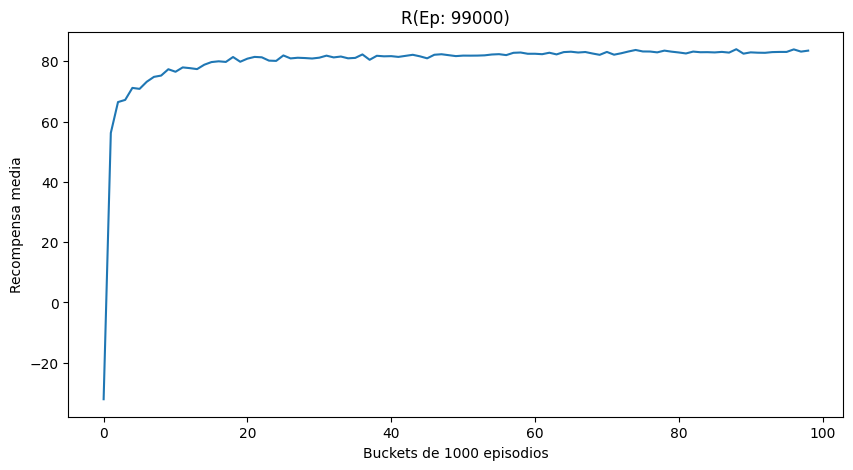

Episodio 100000/100000 | Metas: 99903 | Mejor: 7 pasos
Mejor trayectoria: 7 pasos


In [307]:
# Creamos un agente con Q-table inicializada pesimistamente
on_policy_agent = Eps_soft_policy_agent(0.2, t1.rows, t1.columns)  # Más exploración inicial
num_episodes = 100000
discount = 0.7

trainer = Train(t1, on_policy_agent)
trainer.entrenar_on_policy(num_episodes, discount, plot_reward=True, plot_interval=10000)

# Entrenamiento Off-policy

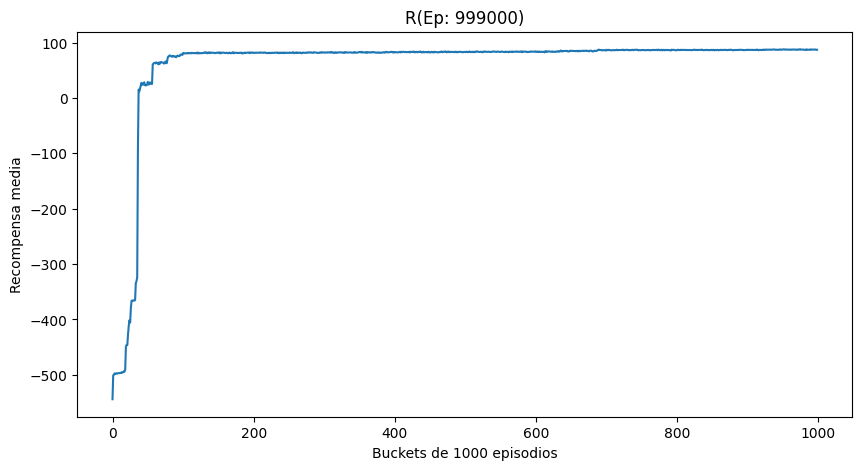

Episodio 1000000/1000000 | Metas: 963926 | Mejor: 8 pasos
Mejor trayectoria: 8 pasos


In [308]:
off_policy_agent = Eps_soft_policy_agent(0.05, t1.rows, t1.columns)  # Más exploración inicial
num_episodes = 1000000
discount = 0.7

trainer = Train(t1, off_policy_agent)
trainer.entrenar_off_policy(num_episodes, discount, plot_reward=True, plot_interval=1000000)

# Heatmaps (Visualizacion de la Q-table)

Como ya hemos visto, la Q-table asocia cada par estado-accion con su valor Q(s, a), que nos sirve para evaluar una determinada accion en un estado concreto con el resto de acciones posibles, de manera que podemos seleccionar la mejor accion. Este valor es una matriz de tamaño (alto_tablero, ancho_tablero, velocidad_fila, velocidad_columna, accion_i, accion_j), de modo que no se puede visualizar sin agragar mucha informacion.

Hemos diseñado un un plot que muestra por cada direccion posible en la accion (Arriba, Abajo, Izquierda, Derecha), un heat map que hace la media del valor Q(s, a) para todas las velocidades de acuerdo con esa direccion, de modo que se muestra si en una casilla el modelo prefiere moverse en una direccion o otra.

In [309]:
def plot_heatmaps(agent : Eps_soft_policy_agent, tablero : Tablero):

    fig, ax = plt.subplots(2, 2, figsize=(10, 10))
    ax = ax.flatten()

    q_table = agent.Q_table.Q_table
    directions = [(-1, 0), (0, -1), (0, 1), (1, 0)]  # Arriba, Izquierda, Derecha, Abajo

    for n_plot, dir in enumerate(directions):
        v_dir, h_dir = dir

        img = np.zeros((tablero.rows, tablero.columns), dtype=float)

        match v_dir, h_dir:
            case (-1, 0):
                title = "Heatmap UP"
                speed_v_idx = slice(0, 5)     
                speed_h_idx = 5
            case (0, -1):
                title = "Heatmap LEFT"
                speed_v_idx = slice(0, 0)    
                speed_h_idx = 5
            case (0, 1):
                title = "Heatmap RIGHT"
                speed_v_idx = 5
                speed_h_idx = slice(6, 11)     
            case (1, 0):
                title = "Heatmap DOWN"
                speed_v_idx = slice(6, 11)     
                speed_h_idx = 5


        a_v = v_dir + 1
        a_h = h_dir + 1

        for i in range(img.shape[0]):
            for j in range(img.shape[1]):

                q_values = q_table[i, j, speed_v_idx, speed_h_idx, a_v, a_h]
                repr_q_value = np.mean(np.sort(np.ravel(q_values))[-3:])  # Media de los 3 mejores Q-values
                img[i, j] = repr_q_value

        plt.sca(ax[n_plot])
        plt.title(title)
        plt.axis('off')
        im = plt.imshow(img, cmap='hot', interpolation='nearest')


    plt.show()

# Heat map on policy

/var/data/python/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/var/data/python/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


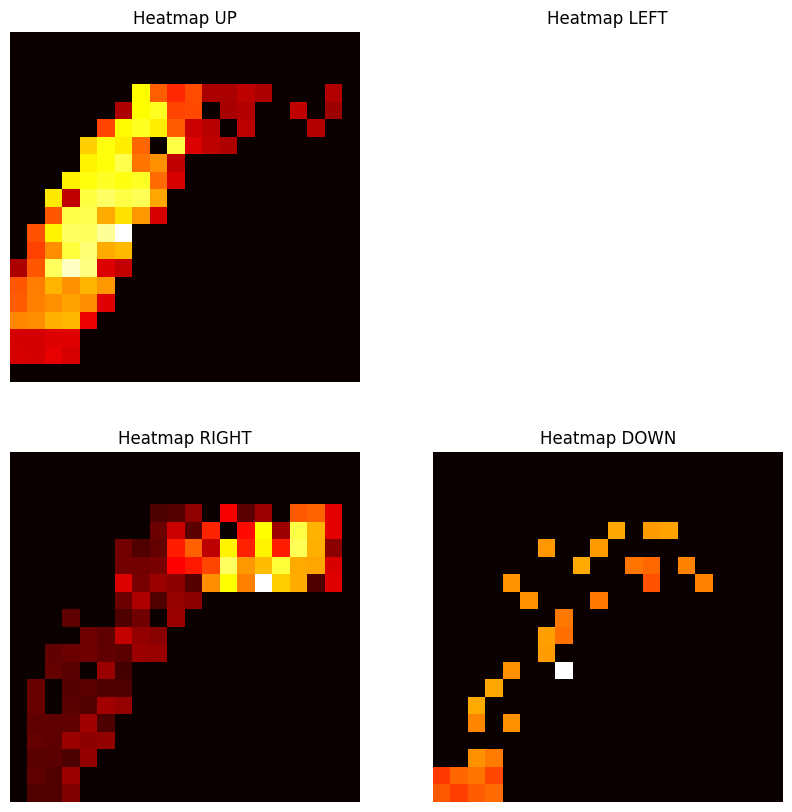

In [310]:
plot_heatmaps(on_policy_agent, t1)

# Heatmaps off policy

/var/data/python/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/var/data/python/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


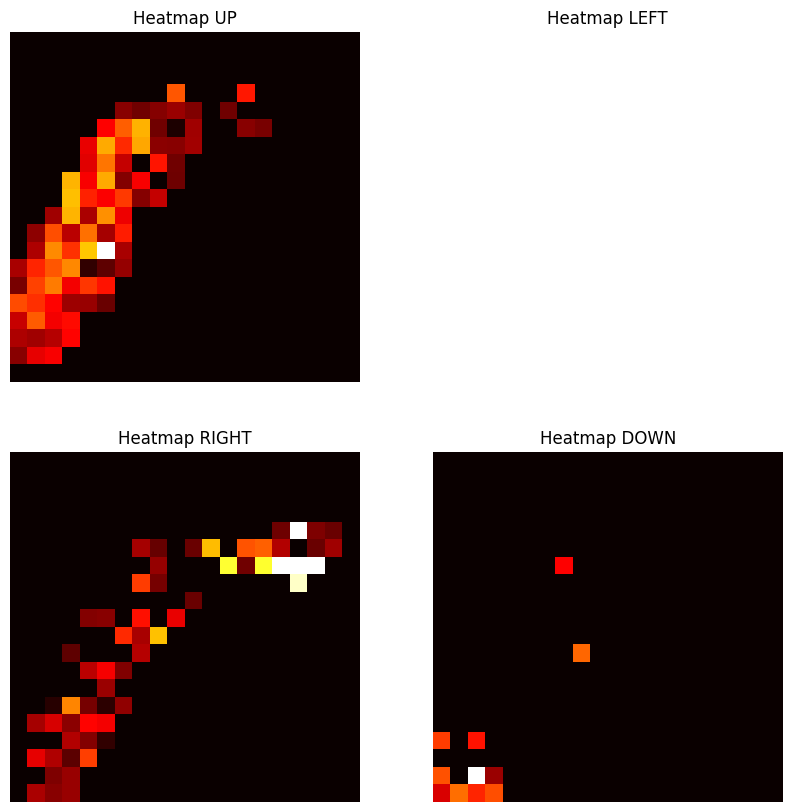

In [330]:
plot_heatmaps(off_policy_agent, t1)

# Agente entrenado

Aqui podemos ver tambien un ejemplo de partida del agente entrenado desactivando el modo entrenamiento, (epsilon = 0).

In [333]:
game = Game(t1)
off_policy_agent.explore = False
final_traza = game.simulate_episode(off_policy_agent, max_states=200)
off_policy_agent.explore = True

print("Traza final del agente entrenado:")
for step, (state, action, reward) in enumerate(final_traza.traza):
    print(f"Paso {step + 1}: Estado: {state}, Acción: {action}, Recompensa: {reward}")

Traza final del agente entrenado:
Paso 1: Estado: Pos: (19, 1), Vel: (0, 0), Acción: (-1, 0), Recompensa: -1
Paso 2: Estado: Pos: (18, 1), Vel: (-1, 0), Acción: (-1, 1), Recompensa: -1
Paso 3: Estado: Pos: (16, 2), Vel: (-2, 1), Acción: (0, 1), Recompensa: -1
Paso 4: Estado: Pos: (14, 4), Vel: (-2, 2), Acción: (0, 1), Recompensa: -1
Paso 5: Estado: Pos: (12, 7), Vel: (-2, 3), Acción: (-1, -1), Recompensa: -1
Paso 6: Estado: Pos: (9, 9), Vel: (-3, 2), Acción: (0, 1), Recompensa: -1
Paso 7: Estado: Pos: (6, 12), Vel: (-3, 3), Acción: (1, 0), Recompensa: -1
Paso 8: Estado: Pos: (4, 15), Vel: (-2, 3), Acción: (1, 1), Recompensa: 100


## Visualizacion de traza del agente entrenado

In [350]:
def dibujar_traza(tablero : Tablero, traza : Traza, final_pos):
    print(traza.traza[0].position)
    img = tablero.tablero.copy()
    posiciones_coche = [step[0].position for step in traza.traza] + [final_pos]


    for pos in posiciones_coche:
        img[pos] = 4  # Marcamos la posición del coche en la traza con un valor distinto
    colores = {
        0: (0, 0, 0),
        1: (255, 255, 255),
        2: (255, 0, 0),
        3: (0, 255, 0),
        4: (0, 0, 255)  # Azul para la traza del coche
    }

    plt.axis('off')
    img_rgb = np.zeros((tablero.rows, tablero.columns, 3), dtype=np.uint8)
    for i in range(tablero.rows):
        for j in range(tablero.columns):
            img_rgb[i, j] = colores[img[i, j]]
    plt.imshow(img_rgb)

    # Ploteamos flechas para la traza del coche
    for step in traza.traza[:]:
        state = step[0]
        ac = step[1]
        pos = state.position
        vel = [state.velocity[0] + ac[0], state.velocity[1] + ac[1]] 
        plt.arrow(pos[1], pos[0], vel[1]*0.8, vel[0]*0.8, head_width=0.3, head_length=0.3, fc='yellow', ec='yellow')
    plt.show()

# Traza agente on-policy

Para generar esta traza desactivamos la exploracion para usar una estrategia greedy respecto del valor maximo de la tabla q.

In [351]:
game = Game(t1)
on_policy_agent.explore = False
final_traza = game.simulate_episode(on_policy_agent, max_states=200)
final_pos = on_policy_agent.state.position
on_policy_agent.explore = True

dibujar_traza(t1, final_traza, final_pos)

AttributeError: 'list' object has no attribute 'position'

In [349]:
final_traza.traza[3][0].position

(14, 4)